<a href="https://colab.research.google.com/github/Siddharth5723/Daily_learning/blob/main/L1_and_L2_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# L1 and L2 Regularization

## Introduction to Regularization

Regularization is a technique used in machine learning to prevent overfitting. Overfitting occurs when a model learns the training data too well, including its noise and random fluctuations, which leads to poor performance on unseen data.

Regularization works by adding a penalty term to the loss function during model training. This penalty term discourages the model from assigning excessively large weights to features, thereby simplifying the model and improving its generalization capabilities.

## L1 Regularization (Lasso Regression)

L1 regularization, also known as Lasso (Least Absolute Shrinkage and Selection Operator) regularization, adds a penalty equal to the absolute value of the magnitude of the coefficients to the loss function.

### Mathematical Form

For a linear regression model, the objective function with L1 regularization is:

$Cost Function = RSS + \lambda \sum_{j=1}^{p} |\beta_j|$

Where:
*   $RSS$ is the Residual Sum of Squares (the standard loss function).
*   $\lambda$ (lambda) is the regularization parameter, which controls the strength of the penalty. A larger $\lambda$ means stronger regularization.
*   $\beta_j$ are the model coefficients.

### Key Characteristics:
*   **Feature Selection**: L1 regularization has the property of driving some coefficients exactly to zero. This means it can effectively perform automatic feature selection, making it useful when you have many features and want to identify the most important ones.
*   **Sparsity**: It encourages sparse models where many coefficients are zero.

Let's see an example using `scikit-learn`.

Linear Regression MSE: 3.57
Linear Regression Coefficients: [ 1.98480823 -3.03804446  0.48910007 -0.06883404  0.05894182  0.04123761
 -0.04960133 -0.16310078 -0.03543443  0.03838417]

Lasso Regression (alpha=1.0) MSE: 2.99
Lasso Regression Coefficients: [ 1.89649227 -2.86835408  0.277752   -0.          0.          0.
 -0.         -0.01623759 -0.          0.        ]


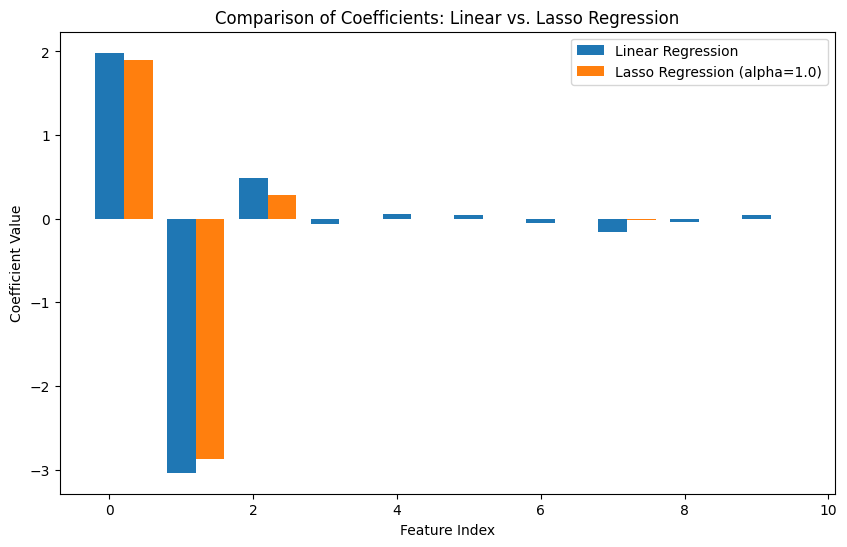

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Generate some synthetic data
np.random.seed(42)
X = np.random.rand(100, 10) * 10  # 100 samples, 10 features
y = 2 * X[:, 0] - 3 * X[:, 1] + 0.5 * X[:, 2] + np.random.randn(100) * 2 # Only a few features are relevant

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a simple Linear Regression model (without regularization)
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
mse_linear = mean_squared_error(y_test, y_pred_linear)
print(f"Linear Regression MSE: {mse_linear:.2f}")
print(f"Linear Regression Coefficients: {linear_model.coef_}")

# Train a Lasso Regression model
# alpha is the regularization parameter (equivalent to lambda)
lasso_model = Lasso(alpha=1.0) # You can experiment with different alpha values
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f"\nLasso Regression (alpha=1.0) MSE: {mse_lasso:.2f}")
print(f"Lasso Regression Coefficients: {lasso_model.coef_}")

# Visualize coefficients
plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), linear_model.coef_, width=0.4, label='Linear Regression')
plt.bar(np.arange(X.shape[1]) + 0.4, lasso_model.coef_, width=0.4, label='Lasso Regression (alpha=1.0)')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Coefficients: Linear vs. Lasso Regression')
plt.legend()
plt.show()

As you can see, Lasso regression has driven several coefficients to exactly zero, effectively performing feature selection. The coefficients of less important features are shrinked towards zero or become zero.

## L2 Regularization (Ridge Regression)

L2 regularization, also known as Ridge regression, adds a penalty equal to the square of the magnitude of the coefficients to the loss function.

### Mathematical Form

For a linear regression model, the objective function with L2 regularization is:

$Cost Function = RSS + \lambda \sum_{j=1}^{p} \beta_j^2$

Where:
*   $RSS$ is the Residual Sum of Squares.
*   $\lambda$ (lambda) is the regularization parameter.
*   $\beta_j$ are the model coefficients.

### Key Characteristics:
*   **Coefficient Shrinkage**: L2 regularization shrinks coefficients towards zero, but it rarely makes them exactly zero. All features tend to be included in the model, but their impact is reduced.
*   **Stability**: It can be more stable when dealing with multicollinearity (highly correlated features), as it distributes the effect of correlated features more evenly.

Let's see an example using `scikit-learn`.

Ridge Regression (alpha=1.0) MSE: 3.56
Ridge Regression Coefficients: [ 1.98188605 -3.03168801  0.48686593 -0.06851644  0.05938389  0.04072926
 -0.0478481  -0.16300087 -0.03519722  0.03695143]


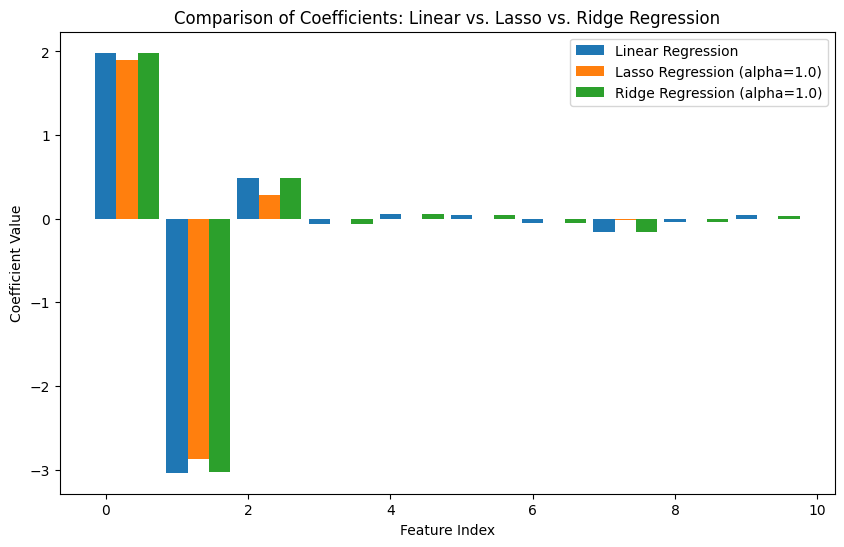

In [8]:
from sklearn.linear_model import Ridge

# Train a Ridge Regression model
# alpha is the regularization parameter (equivalent to lambda)
ridge_model = Ridge(alpha=1.0) # You can experiment with different alpha values
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f"Ridge Regression (alpha=1.0) MSE: {mse_ridge:.2f}")
print(f"Ridge Regression Coefficients: {ridge_model.coef_}")

# Visualize coefficients
plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), linear_model.coef_, width=0.3, label='Linear Regression')
plt.bar(np.arange(X.shape[1]) + 0.3, lasso_model.coef_, width=0.3, label='Lasso Regression (alpha=1.0)')
plt.bar(np.arange(X.shape[1]) + 0.6, ridge_model.coef_, width=0.3, label='Ridge Regression (alpha=1.0)')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.title('Comparison of Coefficients: Linear vs. Lasso vs. Ridge Regression')
plt.legend()
plt.show()

Notice that Ridge regression shrinks the coefficients, but none of them become exactly zero, unlike Lasso.

## L1 vs. L2 Regularization - Key Differences

| Feature           | L1 Regularization (Lasso)           | L2 Regularization (Ridge)             |
|-------------------|-------------------------------------|---------------------------------------|
| **Penalty Term**  | Sum of absolute values of coefficients ($|\beta_j|$) | Sum of squares of coefficients ($\beta_j^2$) |
| **Effect on Coeffs** | Shrinks coefficients to zero (feature selection) | Shrinks coefficients towards zero, but rarely to zero |
| **Sparsity**      | Encourages sparse models           | Does not encourage sparsity           |
| **Use Case**      | When feature selection is desired, or with many irrelevant features | When all features are potentially relevant, or with multicollinearity |
| **Geometric Interpretation** | L1 regularization corresponds to a diamond-shaped constraint region, leading to solutions at the corners (zero coefficients). | L2 regularization corresponds to a circular constraint region, leading to solutions where coefficients are shrunk uniformly. |


## Elastic Net Regularization

Elastic Net regularization combines both L1 and L2 penalties. It is useful when there are multiple correlated features. It addresses some limitations of Lasso (which might arbitrarily pick one feature among correlated ones) and Ridge (which doesn't perform feature selection).

### Mathematical Form

$Cost Function = RSS + \lambda_1 \sum_{j=1}^{p} |\beta_j| + \lambda_2 \sum_{j=1}^{p} \beta_j^2$

Or often expressed with two parameters, alpha (total penalty strength) and l1_ratio (mixing parameter):

$Cost Function = RSS + \alpha \rho \sum_{j=1}^{p} |\beta_j| + \frac{\alpha (1-\rho)}{2} \sum_{j=1}^{p} \beta_j^2$

Where:
*   $\alpha$ controls the overall strength of the regularization.
*   $\rho$ (l1_ratio) is the mixing parameter between L1 and L2. If $\rho=1$, it's Lasso. If $\rho=0$, it's Ridge.

## Conclusion

L1 (Lasso) and L2 (Ridge) regularization are powerful techniques to combat overfitting in machine learning models, especially linear models. Choosing between them, or using Elastic Net, depends on the specific dataset and the modeling goals (e.g., whether feature selection is a priority). The regularization parameter (lambda or alpha) is a crucial hyperparameter that needs to be tuned, often using techniques like cross-validation, to find the optimal balance between bias and variance.